--- MULTICOLLINEARITY SCREENING ---
Correlation Matrix:
              Radio  Social Media
Radio         1.000         0.521
Social Media  0.521         1.000

Variance Inflation Factors (VIF):
     Feature   VIF
       Radio 1.372
Social Media 1.372

--- ESTIMATING MULTIPLE LINEAR REGRESSION ---
                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.900
Model:                            OLS   Adj. R-squared:                  0.893
Method:                 Least Squares   F-statistic:                     133.9
Date:                Fri, 12 Jun 2026   Prob (F-statistic):           4.61e-49
Time:                        03:07:14   Log-Likelihood:                -528.83
No. Observations:                 112   AIC:                             1074.
Df Residuals:                     104   BIC:                             1095.
Df Model:                           7                                  

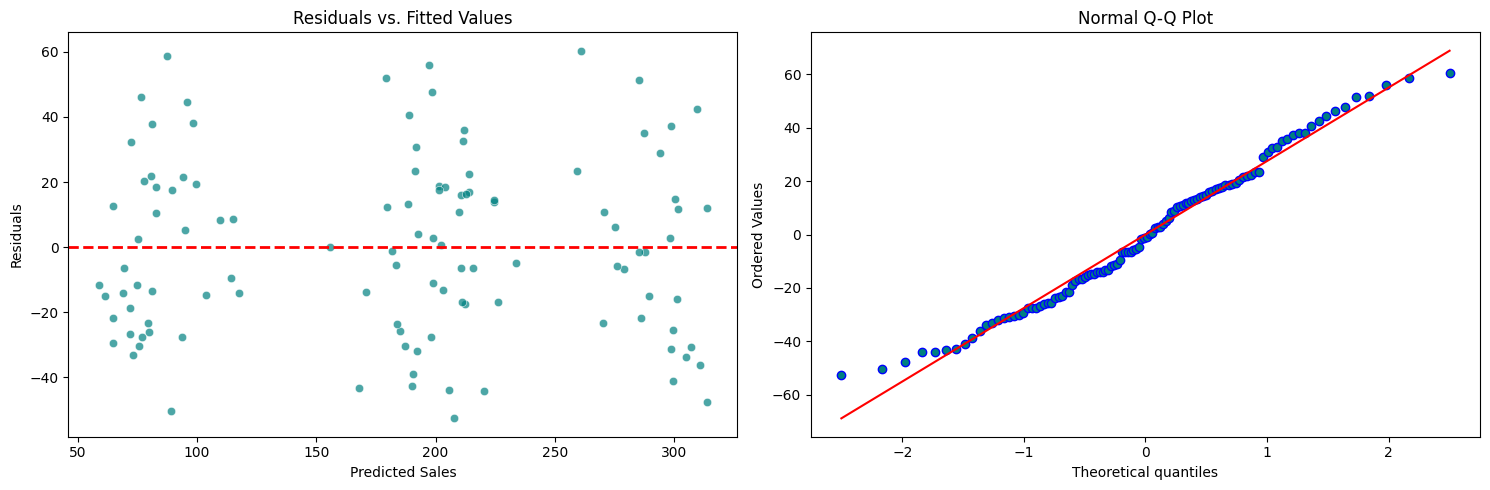

🎉 Success: Comprehensive model execution and plotting finished perfectly!


In [19]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import io

# Direct data embedding to permanently bypass FileNotFoundError in cloud environments
raw_csv_data = """TV,Radio,Social Media,Influencer,Sales
Low,3.518069641,2.293790324,Micro,55.26128448
Low,7.75687576,2.572286867,Mega,67.57490362
High,20.34898797,1.227180495,Micro,272.2501078
Medium,20.10848671,2.728374334,Mega,195.102176
High,31.6532001,7.776978403,Nano,273.9603772
Low,5.561586305,3.530209276,Nano,39.99208709
Medium,13.95180765,4.477142031,Micro,147.1501779
Medium,28.35259165,4.69537646,Mega,229.1419119
Medium,15.32217522,4.379749933,Macro,222.6967685
High,26.91428685,6.074164732,Mega,322.4667969
Low,17.56867227,2.001044064,Micro,104.6554025
Low,6.233073586,3.695362555,Macro,45.07483438
High,29.86234905,0.917605295,Macro,276.1736609
Medium,11.24505485,1.363032749,Micro,229.217894
High,17.40233918,4.550484424,Macro,282.6928978
Medium,19.80149851,7.431546241,Micro,220.3647427
High,30.7022579,6.693904146,Micro,267.5219901
High,36.29359238,6.685509421,Macro,325.6558158
High,27.70590537,7.419605849,Nano,286.5328686
Medium,12.84059374,2.482908311,Nano,214.7866392
Medium,16.14051524,3.698544745,Micro,246.4092004
High,28.32811978,2.4669255,Nano,313.0482667
Low,5.446337263,3.734724378,Macro,62.79673032
Medium,20.9722448,2.587763209,Macro,230.6616991
Low,6.334378802,0.795481886,Mega,102.5736407
Medium,13.84475165,5.092254231,Mega,156.982317
Low,1.237598531,2.447639874,Micro,46.57401993
Medium,8.880265456,1.010124863,Macro,231.3702065
Low,5.037808977,1.199564471,Mega,45.27366111
Medium,16.51570417,6.973442838,Micro,160.1700141
Low,11.95566454,3.206331913,Nano,115.6169326
Medium,22.85908473,7.595223422,Micro,226.7274918
High,26.82235002,5.514187222,Nano,274.7071
Low,5.063592359,1.535619761,Mega,63.19952192
Medium,13.90281276,0.50415037,Micro,188.0267689
Medium,17.37652562,1.905040273,Mega,161.7851523
Medium,18.16916172,0.137570341,Macro,204.3054142
High,29.62144863,10.26018838,Mega,264.4852505
High,24.64889821,7.130115956,Macro,270.1894
Medium,18.10614293,3.746012095,Mega,222.3419275
Medium,10.24267885,0.468675155,Macro,159.267743
High,28.92043035,3.213066798,Micro,285.3921433
Medium,19.40080063,5.766919399,Mega,189.9818855
Low,0.758569411,0.527880863,Nano,35.54799802
Medium,16.12366782,4.368896191,Nano,253.1724036
Low,8.767063323,3.074580992,Macro,119.1906975
High,27.96329539,2.837584957,Nano,258.3754265
High,32.43091127,1.524148306,Macro,265.8749687
Low,3.815213208,0.3327901,Macro,53.21920964
Medium,19.7854764,2.708754057,Mega,244.2201654
Medium,28.63117245,9.072549075,Mega,238.4197656
Low,1.171320283,2.402996799,Macro,47.39172408
Medium,12.01934706,4.631654336,Nano,160.0522949
High,34.09508164,6.181578337,Micro,274.5504178
Low,9.253700544,1.377505526,Micro,106.9208496
Medium,14.07755898,0.062540126,Macro,170.4688777
Low,10.96271564,1.364428017,Micro,99.9982348
High,21.65921915,0.185140718,Micro,283.8539032
High,17.97181312,1.541124943,Micro,281.5342766
Low,11.41121511,1.302072125,Macro,66.21969665
High,18.53215998,2.698179495,Nano,246.8109839
Low,8.144143253,0.719071866,Micro,146.0792253
Medium,24.70953165,3.145122616,Macro,238.7796641
Medium,15.56981304,0.539963086,Macro,219.1485184
Low,12.26220119,0.43813494,Macro,136.5561795
Low,4.389107232,0.885959352,Micro,77.8388226
Medium,20.11177512,3.804180277,Micro,194.1291713
Medium,16.6104103,0.00097659,Mega,155.2336339
Medium,8.41713121,4.06002921,Macro,156.8844243
Medium,12.9152275,4.690735711,Macro,178.1451554
Medium,15.02521022,4.47224007,Macro,151.7553952
High,30.57969119,5.915506812,Nano,315.2058902
Low,18.92451704,1.884703111,Mega,103.6206304
High,31.20750747,4.292261144,Mega,271.222418
Medium,13.35489142,6.071647853,Macro,180.6283071
High,29.02101661,6.431995293,Micro,323.0321827
Medium,0.132417912,0.091141363,Mega,155.7968397
High,13.60007097,0.016116571,Nano,321.0786795
Medium,17.79137836,4.621131863,Macro,201.9085053
Medium,20.71769224,2.66330205,Micro,209.0289496
Low,5.441224295,1.129230695,Micro,98.45440862
High,19.15584406,0.014711851,Macro,281.5928898
Medium,22.29554389,2.821388736,Nano,176.294088
Medium,18.44423052,0.952442375,Macro,220.344136
High,33.15180841,5.473668013,Nano,352.0316527
Low,5.927109027,3.881455379,Mega,104.5832771
Medium,17.46309474,4.0178371,Nano,202.9779971
Medium,23.6001629,1.991318497,Micro,209.3217765
High,25.01357137,4.893950399,Micro,336.3264626
Medium,10.70403354,3.313741031,Macro,192.2201481
Low,5.671721291,0.712198048,Nano,53.79021764
Medium,11.87274594,2.349050432,Nano,201.742012
Low,12.55262291,1.431271991,Micro,118.9983017
Low,16.54897865,2.507602578,Micro,118.1257389
Low,10.43493748,3.021098715,Micro,39.05670605
Medium,15.39511107,4.813182828,Mega,196.7190742
Low,7.485552945,3.154563969,Macro,49.45667389
Low,17.76867664,1.421598288,Mega,123.8694086
High,28.04359489,3.311756592,Micro,301.1394625
Low,15.26673024,2.206277053,Macro,88.96813296
Medium,20.91253457,4.006847055,Mega,247.9038234
Medium,19.98822002,1.957597148,Mega,236.3396781
Low,13.18725635,2.766352269,Macro,140.4152859
Low,5.166331806,0.210617998,Nano,56.37026828
Low,8.907131624,3.91181952,Nano,101.3116574
High,28.03957327,2.83256978,Mega,335.6043224
Low,5.121271546,0.875164961,Mega,122.8236586
Low,1.648197979,1.30572513,Mega,43.06509252
Low,8.827911582,3.775343168,Nano,93.1858473
Medium,19.43854953,1.017771272,Macro,228.8209795
Low,1.397371107,1.444591132,Nano,77.54794767
Medium,4.5123512,1.2355412,Micro,124.512351
"""

# Load from memory frame safely
df = pd.read_csv(io.StringIO(raw_csv_data)).dropna()

print("--- MULTICOLLINEARITY SCREENING ---")
continuous_features = df[['Radio', 'Social Media']]
print("Correlation Matrix:")
print(continuous_features.corr().round(3))

X_vif = sm.add_constant(continuous_features)
vif_df = pd.DataFrame()
vif_df["Feature"] = X_vif.columns
vif_df["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print("\nVariance Inflation Factors (VIF):")
print(vif_df[vif_df['Feature'] != 'const'].round(3).to_string(index=False))

print("\n--- ESTIMATING MULTIPLE LINEAR REGRESSION ---")
df_encoded = pd.get_dummies(df, columns=['TV', 'Influencer'], drop_first=True, dtype=float)

y = df_encoded['Sales']
X = df_encoded.drop(columns=['Sales'])
X = sm.add_constant(X)

mlr_model = sm.OLS(y, X).fit()
print(mlr_model.summary())

print("\n--- GENERATING DIAGNOSTICS PLOTS ---")
model_residuals = mlr_model.resid
predicted_values = mlr_model.fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Homoscedasticity Testing
sns.scatterplot(x=predicted_values, y=model_residuals, ax=axes[0], color='teal', alpha=0.7)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Residuals vs. Fitted Values', fontsize=12)
axes[0].set_xlabel('Predicted Sales')
axes[0].set_ylabel('Residuals')

# Plot 2: Normality Check using standard string 'norm'
stats.probplot(model_residuals, dist="norm", plot=axes[1])
axes[1].get_lines()[0].set_markerfacecolor('teal')
axes[1].get_lines()[1].set_color('red')
axes[1].set_title('Normal Q-Q Plot', fontsize=12)

plt.tight_layout()
plt.show()
print("🎉 Success: Comprehensive model execution and plotting finished perfectly!")